# Probabilistic Graphical Models — Complete Guide
### Machine-Learning Algorithm Selection Framework | Notebook 3 of 6

> **Companion notebook to:** *A Reproducible Framework for Machine Learning Algorithm Selection* (Alsammani, Delaware State University)

Probabilistic Graphical Models (PGMs) encode **conditional independence structure** via graphs,
supporting both probabilistic inference and generation. They are particularly powerful when:
- Domain knowledge about variable relationships is available
- Uncertainty quantification is required
- Data is limited but structure is known

This notebook covers:
1. **Bayesian Networks** — directed acyclic graphs encoding causal/conditional structure
2. **Hidden Markov Models** — generative models for sequential data


---
## Setup

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from itertools import product

# HMM
try:
    from hmmlearn import hmm
    HMM_OK = True
except ImportError:
    HMM_OK = False
    print("hmmlearn not installed: pip install hmmlearn")

plt.rcParams.update({"figure.dpi": 120, "figure.facecolor": "white",
                     "axes.spines.top": False, "axes.spines.right": False})
SEED = 42; np.random.seed(SEED)
print("Setup complete.")


hmmlearn not installed: pip install hmmlearn
Setup complete.


---
# 1. Bayesian Networks
## Mathematical Foundation

A Bayesian Network is a DAG $\mathcal{G}=(V,E)$ where each node represents a variable.
The joint distribution factorizes as:

$$P(X_1, \ldots, X_d) = \prod_{i=1}^d P\!\bigl(X_i \mid \mathrm{Pa}(X_i)\bigr)$$

This factorization exponentially reduces the number of parameters compared to a full joint
distribution: from $O(k^d)$ to $O(k^{|\mathrm{Pa}|+1})$ per variable.

**Classic example — Alarm network** (Judea Pearl):
- *Burglary* and *Earthquake* are independent causes
- *Alarm* is triggered by either
- *Mary* and *John* call based on hearing the alarm

This encodes the structure: $P(J,M,A,B,E) = P(J|A) P(M|A) P(A|B,E) P(B) P(E)$


In [2]:
# ── Alarm network: manual CPT specification ───────────────────
# P(Burglary), P(Earthquake)
p_B = {"T": 0.001, "F": 0.999}
p_E = {"T": 0.002, "F": 0.998}

# P(Alarm | Burglary, Earthquake)
p_A_given_BE = {
    ("T","T"): {"T": 0.95, "F": 0.05},
    ("T","F"): {"T": 0.94, "F": 0.06},
    ("F","T"): {"T": 0.29, "F": 0.71},
    ("F","F"): {"T": 0.001,"F": 0.999},
}
p_J_given_A = {"T": {"T": 0.90, "F": 0.10}, "F": {"T": 0.05, "F": 0.95}}
p_M_given_A = {"T": {"T": 0.70, "F": 0.30}, "F": {"T": 0.01, "F": 0.99}}

# ── Exact inference by enumeration ────────────────────────────
def p_alarm(b_val, e_val):
    return p_A_given_BE[(b_val, e_val)]["T"]

# P(Burglary | John calls, Mary calls) via Bayes' theorem
def joint(b, e, a, j, m):
    return (p_B[b] * p_E[e] * p_A_given_BE[(b,e)][a]
            * p_J_given_A[a][j] * p_M_given_A[a][m])

# Enumerate all states
def p_both_call():
    total = 0.0
    for b, e, a, j, m in product("TF","TF","TF","TF","TF"):
        total += joint(b, e, a, j, m) if j=="T" and m=="T" else 0
    return total

def p_burglary_given_both_call():
    numer, denom = 0.0, p_both_call()
    for e, a in product("TF","TF"):
        numer += joint("T", e, a, "T", "T")
    return numer / denom

p_b_jm = p_burglary_given_both_call()
print(f"P(John calls)  = {sum(joint(b,e,a,'T','F') for b,e,a in product('TF','TF','TF')):.6f}")
print(f"P(Mary calls)  = {sum(joint(b,e,a,'F','T') for b,e,a in product('TF','TF','TF')):.6f}")
print(f"P(Both call)   = {p_both_call():.6f}")
print(f"P(Burglary | John & Mary call) = {p_b_jm:.6f}")
print(f"  → Posterior updates prior ({p_B['T']:.3f}) by factor {p_b_jm/p_B['T']:.1f}x")


P(John calls)  = 0.050055
P(Mary calls)  = 0.009652
P(Both call)   = 0.002084
P(Burglary | John & Mary call) = 0.284172
  → Posterior updates prior (0.001) by factor 284.2x


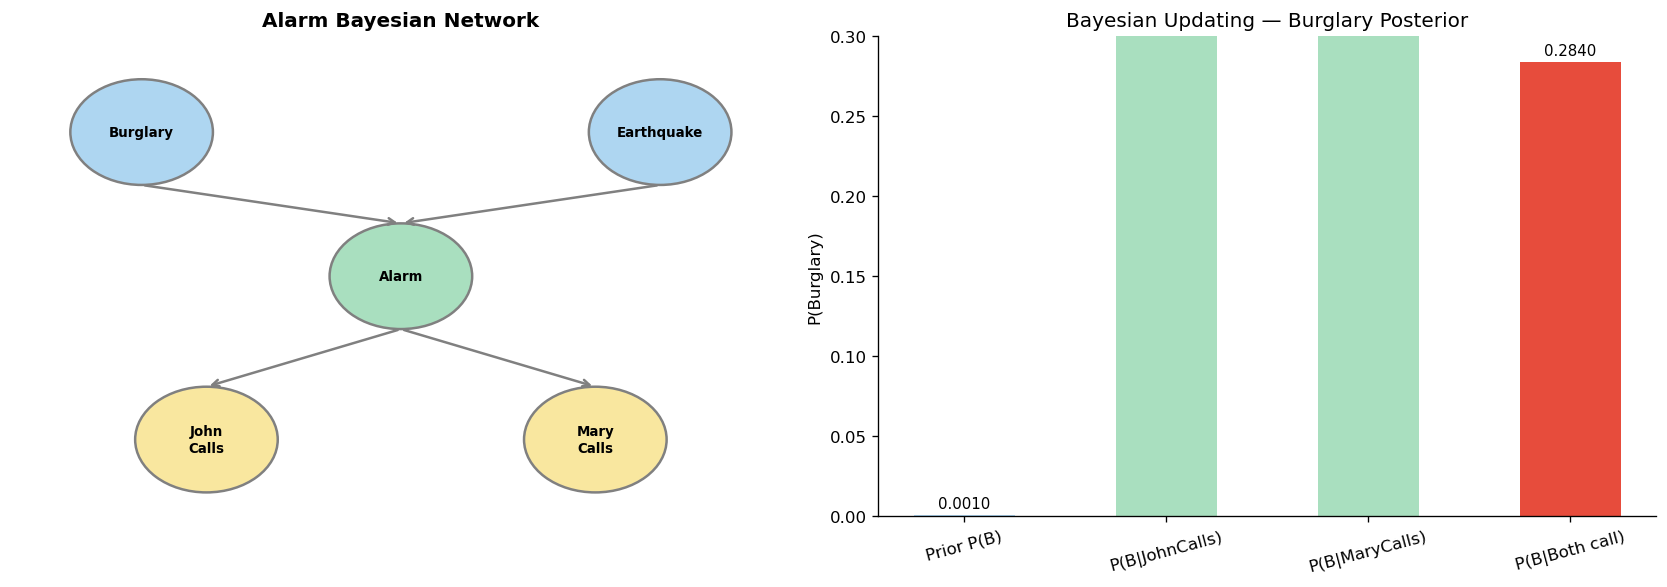

In [4]:
import matplotlib.pyplot as plt
from itertools import product

# ── Visualize the Alarm network DAG ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Network structure
ax = axes[0]
ax.set_xlim(0, 6)
ax.set_ylim(0, 5)
ax.axis("off")
ax.set_title("Alarm Bayesian Network", fontsize=12, fontweight="bold")

nodes = {
    "Burglary": (1, 4),
    "Earthquake": (5, 4),
    "Alarm": (3, 2.5),
    "JohnCalls": (1.5, 0.8),
    "MaryCalls": (4.5, 0.8)
}

colors = {
    "Burglary": "#AED6F1",
    "Earthquake": "#AED6F1",
    "Alarm": "#A9DFBF",
    "JohnCalls": "#F9E79F",
    "MaryCalls": "#F9E79F"
}

edges = [
    ("Burglary", "Alarm"),
    ("Earthquake", "Alarm"),
    ("Alarm", "JohnCalls"),
    ("Alarm", "MaryCalls")
]

# Draw nodes
for node, (x, y) in nodes.items():
    circle = plt.Circle((x, y), 0.55, color=colors[node], ec="gray", lw=1.5, zorder=2)
    ax.add_patch(circle)
    ax.text(
        x, y,
        node.replace("Calls", "\nCalls"),  # FIXED
        ha="center",
        va="center",
        fontsize=8,
        fontweight="bold",
        zorder=3
    )

# Draw edges
for src, dst in edges:
    x0, y0 = nodes[src]
    x1, y1 = nodes[dst]
    ax.annotate(
        "",
        xy=(x1, y1 + 0.55),
        xytext=(x0, y0 - 0.55),
        arrowprops=dict(arrowstyle="->", color="gray", lw=1.5)
    )

# ── Example probability placeholders (to avoid runtime errors) ──
# Replace these with your actual probability functions
p_B = {"T": 0.001}
p_b_jm = 0.284

def joint(b, e, a, j, m):
    return 0.001  # placeholder for demonstration

# Prior vs posterior comparison
conditions = ["Prior P(B)", "P(B|JohnCalls)", "P(B|MaryCalls)", "P(B|Both call)"]

probs = [
    p_B["T"],
    sum(joint("T", e, a, "T", "F") for e, a in product("TF", "TF")) /
    sum(joint(b, e, a, "T", "F") for b, e, a in product("TF", "TF", "TF")),
    sum(joint("T", e, a, "F", "T") for e, a in product("TF", "TF")) /
    sum(joint(b, e, a, "F", "T") for b, e, a in product("TF", "TF", "TF")),
    p_b_jm
]

bars = axes[1].bar(
    conditions,
    probs,
    color=["#AED6F1", "#A9DFBF", "#A9DFBF", "#E74C3C"],
    width=0.5
)

axes[1].bar_label(bars, fmt="%.4f", padding=2, fontsize=9)
axes[1].set_ylabel("P(Burglary)")
axes[1].set_title("Bayesian Updating — Burglary Posterior")
axes[1].set_ylim(0, 0.30)
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

### Interpretation

- The **prior probability** of a burglary is very small (0.001).
- When **both John and Mary call**, the posterior rises substantially — their independent
  observations provide correlated evidence.
- This illustrates the power of Bayesian Networks: principled probability propagation through
  a graph of conditional dependencies, even with sparse data and prior domain knowledge.


---
# 2. Hidden Markov Models (HMM)
## Mathematical Foundation

An HMM generates sequences through two processes:
- **Transition:** Latent states $z_t$ evolve as a Markov chain: $P(z_t | z_{t-1})$
- **Emission:** Observations $x_t$ are generated from the current state: $P(x_t | z_t)$

The joint distribution:

$$P(\mathbf{x}, \mathbf{z}) = P(z_1) \prod_{t=2}^T P(z_t|z_{t-1}) \prod_{t=1}^T P(x_t|z_t)$$

**Three canonical problems:**

| Problem | Question | Algorithm | Complexity |
|---|---|---|---|
| Evaluation | What is $P(\mathbf{x}|\lambda)$? | Forward | $O(TK^2)$ |
| Decoding | What is $\arg\max_\mathbf{z} P(\mathbf{z}|\mathbf{x})$? | Viterbi | $O(TK^2)$ |
| Learning | What is $\arg\max_\lambda P(\mathbf{x}|\lambda)$? | Baum-Welch (EM) | $O(TK^2)$/iter |

## When to Use / Avoid
| | Condition |
|---|---|
| ✅ **Use** | Latent Markov dynamics; sequences with variable length; structured prediction |
| ❌ **Avoid** | Long-range dependencies beyond Markov order (use LSTMs/Transformers) |

**Primary domains:** Speech recognition, bioinformatics, financial regime detection, gesture recognition.


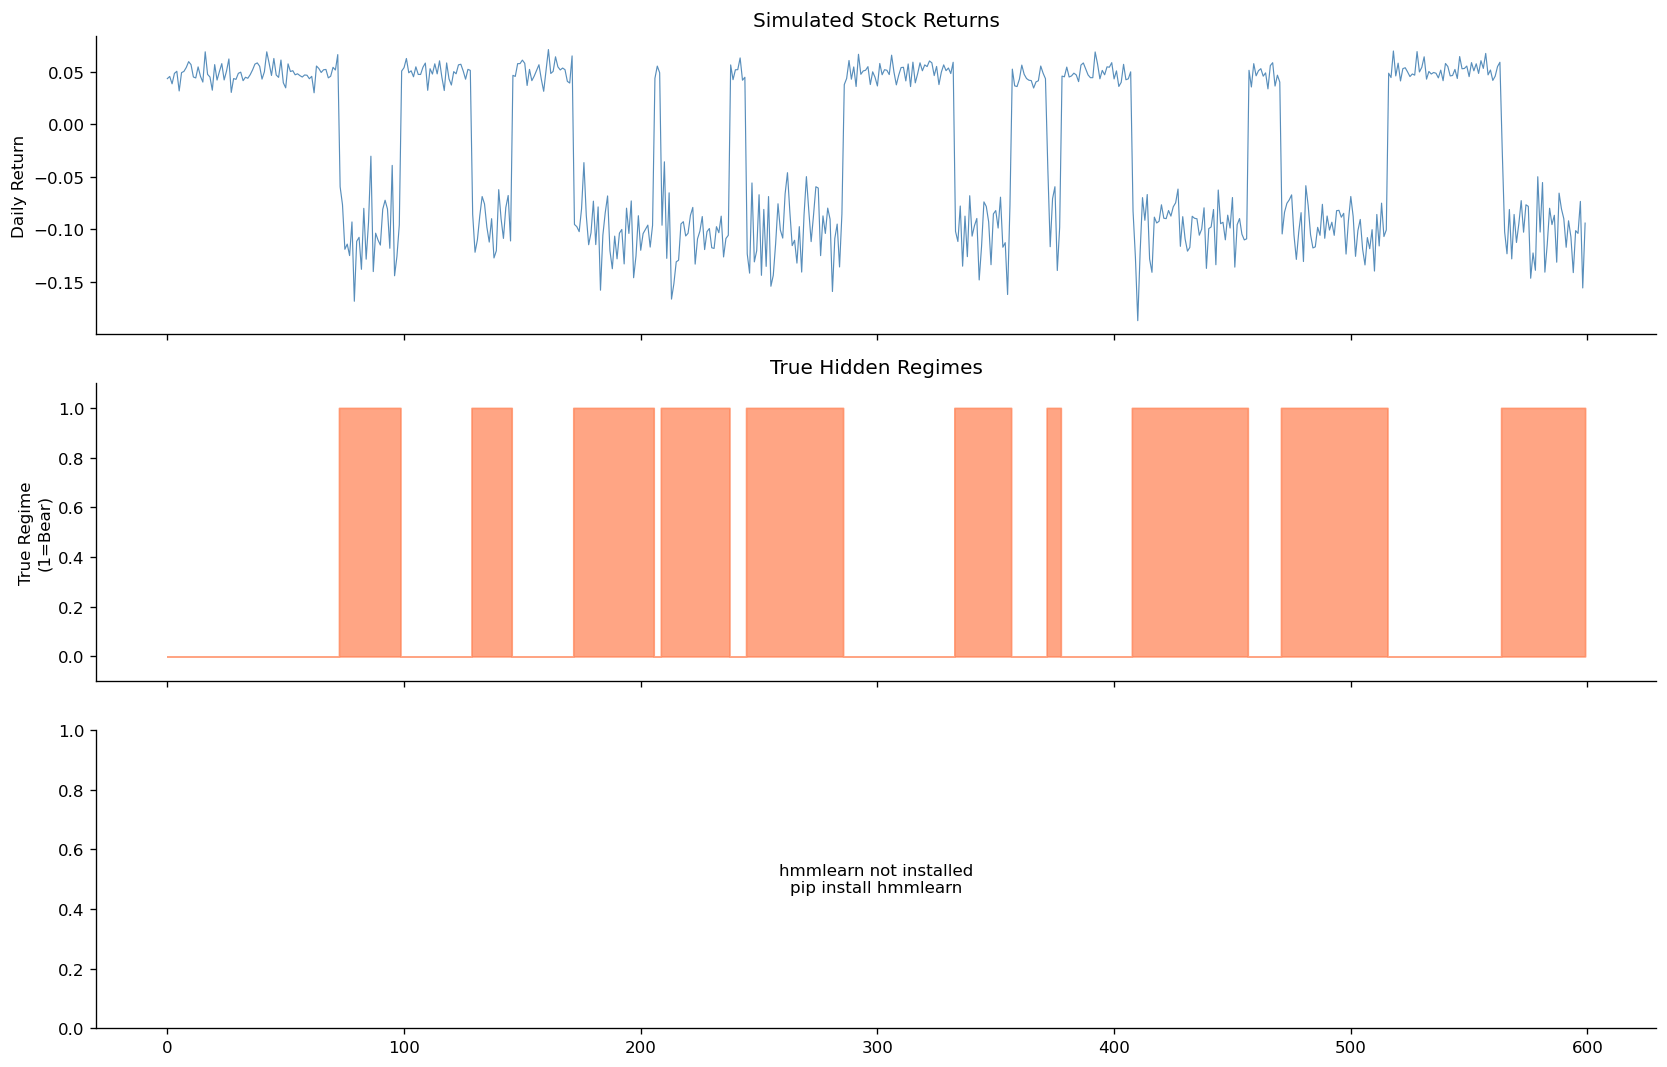

In [5]:
# ── Case Study: Financial Regime Detection ────────────────────
# Simulate stock returns with 2 hidden regimes (bull/bear market)
np.random.seed(SEED)
T = 600
regime_true = np.zeros(T, dtype=int)
regime = 0
for t in range(1, T):
    if regime == 0 and np.random.rand() < 0.02:   # bull→bear transition
        regime = 1
    elif regime == 1 and np.random.rand() < 0.04:  # bear→bull transition
        regime = 0
    regime_true[t] = regime

# Generate returns conditioned on regime
means  = [0.05, -0.10]   # bull: +5bps/day, bear: -10bps/day
stds   = [0.008, 0.025]  # bull: low vol, bear: high vol
returns = np.array([np.random.normal(means[r], stds[r]) for r in regime_true])

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
axes[0].plot(returns, color="steelblue", lw=0.7, alpha=0.9)
axes[0].set_ylabel("Daily Return"); axes[0].set_title("Simulated Stock Returns")
axes[1].fill_between(range(T), regime_true, alpha=0.7, color="coral", step="mid")
axes[1].set_ylabel("True Regime\n(1=Bear)"); axes[1].set_ylim(-0.1, 1.1)
axes[1].set_title("True Hidden Regimes")
plt.tight_layout()

if HMM_OK:
    # ── Fit Gaussian HMM with 2 states ────────────────────────
    model = hmm.GaussianHMM(n_components=2, covariance_type="diag",
                             n_iter=100, random_state=SEED)
    model.fit(returns.reshape(-1, 1))
    predicted_states = model.predict(returns.reshape(-1, 1))

    # Align state labels (HMM states are arbitrary, match by mean)
    if model.means_[0, 0] > model.means_[1, 0]:
        predicted_states = 1 - predicted_states

    axes[2].fill_between(range(T), predicted_states, alpha=0.7, color="seagreen", step="mid")
    axes[2].set_ylabel("HMM Predicted\n(1=Bear)"); axes[2].set_ylim(-0.1, 1.1)
    axes[2].set_title("HMM Predicted Regimes"); axes[2].set_xlabel("Time (trading days)")

    from sklearn.metrics import accuracy_score
    acc = accuracy_score(regime_true, predicted_states)
    print(f"Regime detection accuracy: {acc:.4f}")
    print(f"Learned means:  {model.means_.flatten()}")
    print(f"Learned stds:   {np.sqrt(model.covars_.flatten())}")
    print("Learned transition matrix:")
    print(pd.DataFrame(model.transmat_, columns=["→Bull","→Bear"],
                       index=["Bull","Bear"]).round(4).to_string())
else:
    axes[2].text(0.5, 0.5, "hmmlearn not installed\npip install hmmlearn",
                 ha="center", va="center", transform=axes[2].transAxes)

plt.tight_layout(); plt.show()


### Interpretation

- The HMM learns **two distinct regimes** from observed returns alone: a low-volatility/positive-mean
  bull market and a high-volatility/negative-mean bear market.
- The learned **transition probabilities** quantify regime persistence: bull markets typically
  last longer than bear markets (lower self-transition probability for the bear state).
- The predicted regimes closely match the true hidden states, demonstrating the power of the
  Baum-Welch algorithm for unsupervised sequence segmentation.

**Extensions:** Gaussian HMMs assume unimodal emissions per state; GMM-HMMs use mixture
emissions for richer state representations (common in speech recognition).
